In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import os

os.chdir('..')
sys.path.append('src')

from load_clean import run_pipeline
from cohort_analysis import (
    run_cohort_analysis,
    cohort_tenure_contract,
    cohort_retention_heatmap,
)

df = run_pipeline()

run_cohort_analysis(df)

[2026-03-26 17:24:37,076]: Loading data from: data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
[2026-03-26 17:24:37,267]: Raw data shape: (7043, 21)
[2026-03-26 17:24:37,270]: Cleaning data...
[2026-03-26 17:24:37,441]: Cleaned data shape: (7043, 26) | Churn rate: 26.54%
[2026-03-26 17:24:37,597]: Saved to: data\processed\telco_cleaned.csv
[2026-03-26 17:24:37,598]: Pipeline complete!
[2026-03-26 17:24:37,602]: Running cohort analysis...
[2026-03-26 17:24:37,643]: 
Cohort — Tenure x Contract:
   tenure_band        contract  total  churned  retention_rate  churn_rate
0      0–12 mo  Month-to-month   1994     1024        0.486459    0.513541
1      0–12 mo        One year    124       13        0.895161    0.104839
2      0–12 mo        Two year     68        0        1.000000    0.000000
3     13–24 mo  Month-to-month    737      278        0.622795    0.377205
4     13–24 mo        One year    197       16        0.918782    0.081218
5     13–24 mo        Two year     90        0        1

In [2]:
cohort_tenure_contract(df)

[2026-03-26 17:25:00,265]: 
Cohort — Tenure x Contract:
   tenure_band        contract  total  churned  retention_rate  churn_rate
0      0–12 mo  Month-to-month   1994     1024        0.486459    0.513541
1      0–12 mo        One year    124       13        0.895161    0.104839
2      0–12 mo        Two year     68        0        1.000000    0.000000
3     13–24 mo  Month-to-month    737      278        0.622795    0.377205
4     13–24 mo        One year    197       16        0.918782    0.081218
5     13–24 mo        Two year     90        0        1.000000    0.000000
6     25–36 mo  Month-to-month    486      158        0.674897    0.325103
7     25–36 mo        One year    250       20        0.920000    0.080000
8     25–36 mo        Two year     96        2        0.979167    0.020833
9     37–48 mo  Month-to-month    316      106        0.664557    0.335443
10    37–48 mo        One year    268       35        0.869403    0.130597
11    37–48 mo        Two year    178       

,tenure_band,contract,total,churned,retention_rate,churn_rate
0,0–12 mo,Month-to-month,1994,1024,0.486459,0.513541
1,0–12 mo,One year,124,13,0.895161,0.104839
2,0–12 mo,Two year,68,0,1.000000,0.000000
3,13–24 mo,Month-to-month,737,278,0.622795,0.377205
4,13–24 mo,One year,197,16,0.918782,0.081218
5,13–24 mo,Two year,90,0,1.000000,0.000000
6,25–36 mo,Month-to-month,486,158,0.674897,0.325103
7,25–36 mo,One year,250,20,0.920000,0.080000
8,25–36 mo,Two year,96,2,0.979167,0.020833
9,37–48 mo,Month-to-month,316,106,0.664557,0.335443


In [3]:
cohort_retention_heatmap(df)

[2026-03-26 17:25:18,928]: 
Retention Heatmap Data:
contract     Month-to-month  One year  Two year
tenure_band                                    
0–12 mo                51.4      10.5       0.0
13–24 mo               37.7       8.1       0.0
25–36 mo               32.5       8.0       2.1
37–48 mo               33.5      13.1       2.2
49–60 mo               27.8      13.7       4.0
61–72 mo               22.2      12.1       3.1
[2026-03-26 17:25:19,698]: Saved: cohort_heatmap.png


contract,Month-to-month,One year,Two year
tenure_band,,,
0–12 mo,51.4,10.5,0.0
13–24 mo,37.7,8.1,0.0
25–36 mo,32.5,8.0,2.1
37–48 mo,33.5,13.1,2.2
49–60 mo,27.8,13.7,4.0
61–72 mo,22.2,12.1,3.1


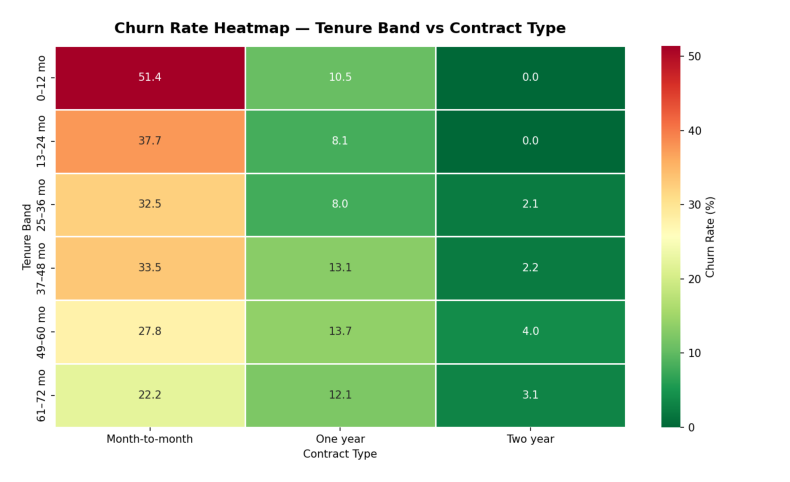

In [4]:
img = mpimg.imread('reports/figures/cohort_heatmap.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

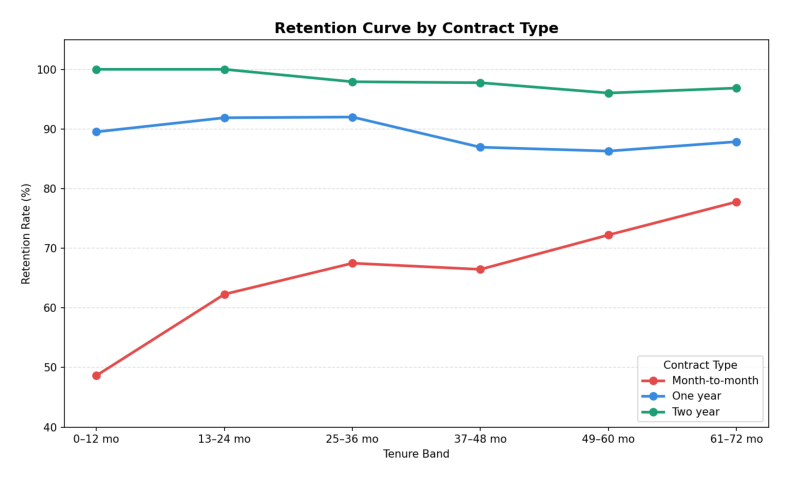

In [5]:
img = mpimg.imread('reports/figures/retention_curve_by_contract.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
df.groupby(
    ['tenure_band', 'internetservice'], observed=True
)['churn'].mean().mul(100).round(2).unstack()

internetservice,DSL,Fiber optic,No
tenure_band,,,
0–12 mo,40.00,69.88,17.93
13–24 mo,19.64,48.78,3.77
25–36 mo,8.54,39.63,2.94
37–48 mo,13.16,33.13,0.60
49–60 mo,7.02,24.61,3.11
61–72 mo,2.78,12.42,0.36


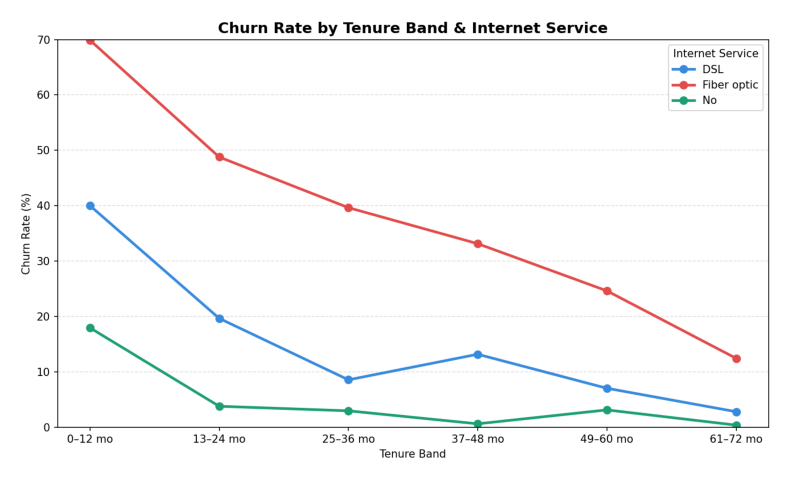

In [7]:
img = mpimg.imread('reports/figures/cohort_tenure_internet.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
df.groupby(
    ['tenure_band', 'churn_label'], observed=True
).size().unstack('churn_label').fillna(0).astype(int)

churn_label,Churned,Retained
tenure_band,,
0–12 mo,1037,1149
13–24 mo,294,730
25–36 mo,180,652
37–48 mo,145,617
49–60 mo,120,712
61–72 mo,93,1314


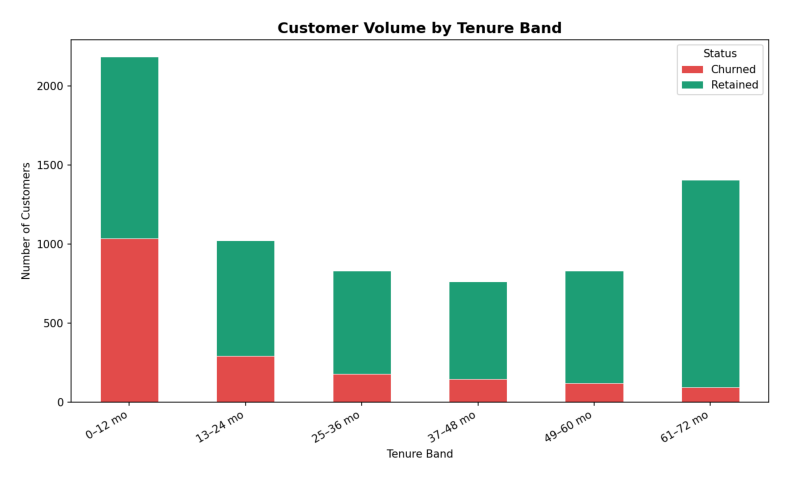

In [9]:
img = mpimg.imread('reports/figures/cohort_volume.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()